# Prediction Markets as a Derivative: Binary Options, the Black-Scholes PDE, and Bounded Martingales

This notebook frames a prediction-market (PM) YES/NO contract as a **binary (cash-or-nothing) option**
and explores its pricing and hedging properties through two consistent lenses:

1. **The Black-Scholes closed-form formula** -- a PM price is literally e^{-rT} N(d2).
2. **The Crank-Nicolson PDE solver** -- the same price drops out of the BS PDE with a step payoff.
3. **The native bounded-martingale view** -- we model the PM price directly as p_t = N(X_t / sqrt(T-t)),
   study its Ito dynamics, and show that 'probability vol' explodes near resolution.

All data and paths are **synthetic / seed-reproducible**; no live market data is used.
The full theoretical discussion (Q vs P measure, favourite-longshot bias) lives in
`reports/PREDICTION_MARKETS_AS_DERIVATIVES.md` -- this notebook focuses on simulation evidence.


In [1]:
import sys
sys.path.insert(0, "..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm

plt.rcParams.update({"figure.dpi": 110, "font.size": 11})

from config import SEED, DEFAULT_RISK_FREE_RATE, DEFAULT_TRANSACTION_COST
from models.black_scholes import BlackScholes
from models.pde_solver import CrankNicolsonBS

rng = np.random.default_rng(SEED)

# Reference contract anchor
S0, K0, T0, r = 100.0, 100.0, 1.0, DEFAULT_RISK_FREE_RATE
sigma0 = 0.20

COLORS = {
    "analytic": "black",
    "pde":      "steelblue",
    "parity":   "darkorange",
    "delta":    "seagreen",
    "path":     "mediumpurple",
    "pdf":      "crimson",
    "signal":   "goldenrod",
    "longshot": "tomato",
}

print(f"SEED={SEED}, r={r:.4f}, sigma={sigma0}, S={S0}, K={K0}, T={T0}")


SEED=42, r=0.0438, sigma=0.2, S=100.0, K=100.0, T=1.0


---
## 1 | Framing a Prediction Market as a Binary Option

A prediction market (PM) contract pays **\$1 if an event E occurs** and \$0 otherwise.
If we model the event as {S_T > K} where S_t is a GBM representing the signal underlying
the event, the contract is exactly a **cash-or-nothing (digital) call option**:

$$C_{\text{dig}} = e^{-rT} \, N(d_2), \qquad d_2 = \frac{\ln(S/K) + (r - \tfrac{1}{2}\sigma^2)T}{\sigma\sqrt{T}}$$

The factor e^{-rT} discounts the probability N(d_2) to present value. For small r and short T this
is essentially the **risk-neutral probability** of the event: p ~ N(d_2).

**Binary put-call parity.** The complementary NO contract (pays \$1 if S_T <= K) is a digital put:

$$P_{\text{dig}} = e^{-rT} N(-d_2)$$

Together they exhaust the state space:

$$C_{\text{dig}} + P_{\text{dig}} = e^{-rT} \approx \$1 \quad (\text{for small } r)$$

The YES + NO portfolio is a risk-free bond maturing at T -- a clean parity relationship.


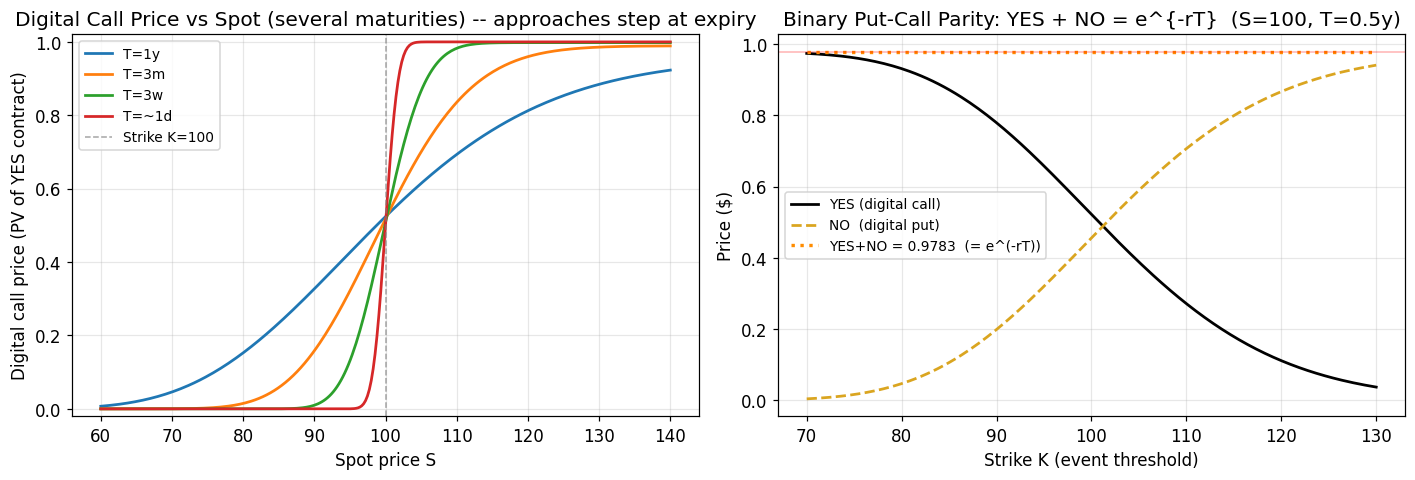

Fig 1 saved.

Reference contract (S=K=100, T=1y, r=0.0438, sigma=0.20):
  Digital call (YES)  = 0.523905
  Digital put  (NO)   = 0.433240
  Sum (YES+NO)        = 0.957145
  e^(-rT)             = 0.957145
  Parity error        = 0.00e+00


In [2]:
# Digital call price vs spot for several maturities
S_range = np.linspace(60, 140, 300)
maturities = [1.0, 0.25, 0.05, 0.005]
maturity_labels = ["T=1y", "T=3m", "T=3w", "T=~1d"]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

ax = axes[0]
for T_val, lbl in zip(maturities, maturity_labels):
    prices = [BlackScholes(S, K0, T_val, r, sigma0).digital_call_price() for S in S_range]
    ax.plot(S_range, prices, label=lbl, linewidth=1.8)

ax.axvline(K0, color="grey", linestyle="--", linewidth=1, alpha=0.7, label="Strike K=100")
ax.set_xlabel("Spot price S")
ax.set_ylabel("Digital call price (PV of YES contract)")
ax.set_title("Digital Call Price vs Spot (several maturities) -- approaches step at expiry")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_ylim(-0.02, 1.02)

# Binary put-call parity: YES + NO = e^{-rT}
ax2 = axes[1]
K_range = np.linspace(70, 130, 200)
T_par = 0.5  # 6-month contracts

yes_prices = [BlackScholes(S0, K, T_par, r, sigma0).digital_call_price() for K in K_range]
no_prices  = [BlackScholes(S0, K, T_par, r, sigma0).digital_put_price()  for K in K_range]
sum_prices = np.array(yes_prices) + np.array(no_prices)
disc_half  = np.exp(-r * T_par)

ax2.plot(K_range, yes_prices, color=COLORS["analytic"], label="YES (digital call)", linewidth=1.8)
ax2.plot(K_range, no_prices,  color=COLORS["signal"],   label="NO  (digital put)",  linewidth=1.8, linestyle="--")
ax2.plot(K_range, sum_prices, color=COLORS["parity"],
         label=f"YES+NO = {disc_half:.4f}  (= e^(-rT))", linewidth=2.2, linestyle=":")
ax2.axhline(disc_half, color="red", alpha=0.3, linewidth=1)
ax2.set_xlabel("Strike K (event threshold)")
ax2.set_ylabel("Price ($)")
ax2.set_title("Binary Put-Call Parity: YES + NO = e^{-rT}  (S=100, T=0.5y)")
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print("Fig 1 saved.")

# Tabulate reference prices
print(f"\nReference contract (S=K=100, T=1y, r={r:.4f}, sigma=0.20):")
bs_ref = BlackScholes(S0, K0, T0, r, sigma0)
dc = bs_ref.digital_call_price()
dp = bs_ref.digital_put_price()
disc = np.exp(-r * T0)
print(f"  Digital call (YES)  = {dc:.6f}")
print(f"  Digital put  (NO)   = {dp:.6f}")
print(f"  Sum (YES+NO)        = {dc+dp:.6f}")
print(f"  e^(-rT)             = {disc:.6f}")
print(f"  Parity error        = {abs(dc+dp - disc):.2e}")


---
## 2 | The Hedging Problem: Digital Delta Spikes Near Expiry

The delta of a digital call is:

$$\frac{\partial C_{\text{dig}}}{\partial S} = e^{-rT} \frac{\phi(d_2)}{S \sigma \sqrt{T}}$$

As T -> 0 with S near K, the Gaussian PDF phi(d_2) spikes like a Dirac delta. The hedge ratio
**blows up** -- no finite position in the underlying can replicate a discontinuous payoff without
infinite trading costs. This is why dealers typically approximate binaries with tight **call-spreads**
(long K-epsilon / short K+epsilon vanilla calls), which are continuous and hedgeable.

Below we plot digital delta vs spot for shrinking maturities to visualise the spike.


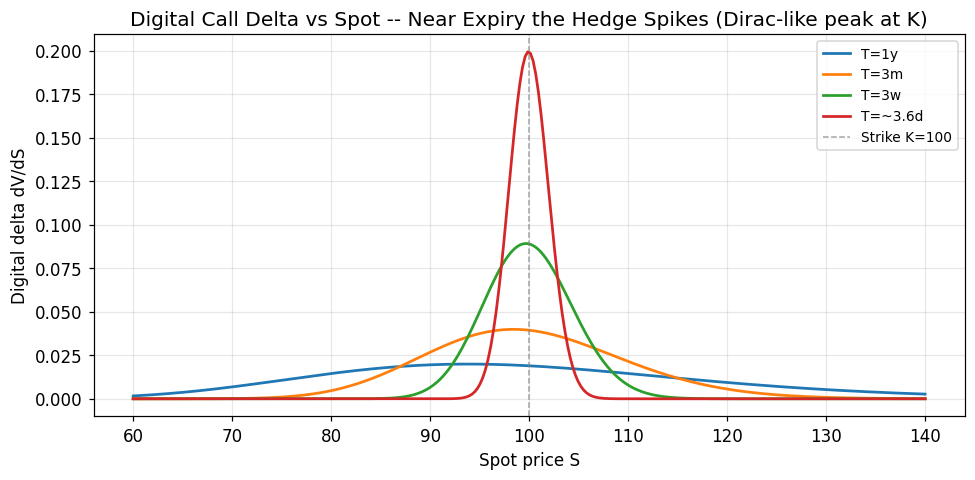

Peak digital delta at S=K (ATM) for each maturity:
  T=1y: delta=0.0190
  T=3m: delta=0.0394
  T=3w: delta=0.0890
  T=~3.6d: delta=0.1994


In [3]:
# Digital delta spikes as T -> 0 -- the hedging impossibility
fig, ax = plt.subplots(figsize=(9, 4.5))

maturities_delta = [1.0, 0.25, 0.05, 0.01]
labels_delta     = ["T=1y", "T=3m", "T=3w", "T=~3.6d"]

for T_val, lbl in zip(maturities_delta, labels_delta):
    deltas = [BlackScholes(S, K0, T_val, r, sigma0).digital_delta("call") for S in S_range]
    ax.plot(S_range, deltas, label=lbl, linewidth=1.8)

ax.axvline(K0, color="grey", linestyle="--", linewidth=1, alpha=0.7, label="Strike K=100")
ax.set_xlabel("Spot price S")
ax.set_ylabel("Digital delta dV/dS")
ax.set_title("Digital Call Delta vs Spot -- Near Expiry the Hedge Spikes (Dirac-like peak at K)")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_ylim(-0.01, None)

plt.tight_layout()
plt.show()

# Print peak delta values
print("Peak digital delta at S=K (ATM) for each maturity:")
for T_val, lbl in zip(maturities_delta, labels_delta):
    d_atm = BlackScholes(K0, K0, T_val, r, sigma0).digital_delta("call")
    print(f"  {lbl}: delta={d_atm:.4f}")


---
## 3 | Binary Pricing via the BS PDE (Finite Differences)

The Black-Scholes PDE is:

$$\frac{\partial V}{\partial t} + \tfrac{1}{2}\sigma^2 S^2 \frac{\partial^2 V}{\partial S^2} + rS \frac{\partial V}{\partial S} - rV = 0$$

Solved **backward in time** from the terminal payoff at t = T. For a digital call, the payoff is
the step function V(S, T) = 1_{S > K} -- a discontinuity that creates Gibbs-like oscillations
under standard Crank-Nicolson.

**Rannacher smoothing** fixes this: the first two backward time steps use the fully-implicit scheme
(theta = 1, strongly dissipative), then switch to Crank-Nicolson (theta = 0.5, 2nd-order accurate).
Two implicit steps suffice to damp the jump before CN takes over.

We compare the PDE price to the closed-form e^{-rT} N(d2) across a range of strikes.


PDE vs Analytic digital call price (S=100, T=1y, sigma=0.20):
          Analytic e^(-rT)N(d2)  PDE (CN+Rannacher) Abs Error
Strike K                                                     
80                     0.853326            0.853306  1.95e-05
85                     0.788905            0.793879  4.97e-03
90                     0.709050            0.709182  1.32e-04
95                     0.618644            0.612461  6.18e-03
100                    0.523905            0.523923  1.80e-05
105                    0.430985            0.430964  2.06e-05
110                    0.344897            0.344897  7.86e-07
115                    0.268978            0.269008  2.94e-05
120                    0.204832            0.204938  1.06e-04


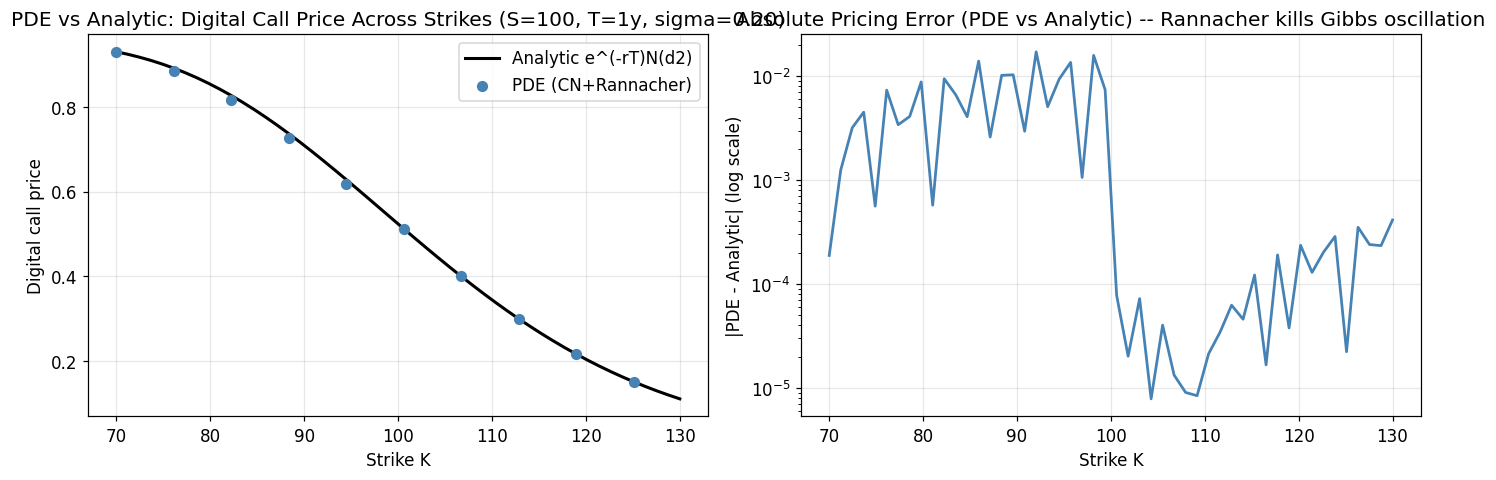


Max absolute error across strikes: 1.72e-02


In [4]:
# PDE vs analytic across strikes
K_test = np.array([80, 85, 90, 95, 100, 105, 110, 115, 120])
T_pde  = 1.0

rows = []
for K_val in K_test:
    analytic  = BlackScholes(S0, K_val, T_pde, r, sigma0).digital_call_price()
    pde_price = CrankNicolsonBS(S0, K_val, T_pde, r, sigma0, M=300, N=300, rannacher=True).price(
        "call", payoff="digital"
    )
    rows.append({
        "Strike K":              K_val,
        "Analytic e^(-rT)N(d2)": round(analytic, 6),
        "PDE (CN+Rannacher)":    round(pde_price, 6),
        "Abs Error":             f"{abs(pde_price - analytic):.2e}",
    })

df_pde = pd.DataFrame(rows).set_index("Strike K")
print("PDE vs Analytic digital call price (S=100, T=1y, sigma=0.20):")
print(df_pde.to_string())

# Plot
K_plot = np.linspace(70, 130, 50)
analytic_prices = [BlackScholes(S0, K, T_pde, r, sigma0).digital_call_price() for K in K_plot]
pde_prices = [
    CrankNicolsonBS(S0, K, T_pde, r, sigma0, M=200, N=200, rannacher=True).price("call", payoff="digital")
    for K in K_plot
]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))

ax1.plot(K_plot, analytic_prices, color=COLORS["analytic"], linewidth=2, label="Analytic e^(-rT)N(d2)")
ax1.scatter(K_plot[::5], pde_prices[::5], color=COLORS["pde"], s=40, zorder=5, label="PDE (CN+Rannacher)")
ax1.set_xlabel("Strike K")
ax1.set_ylabel("Digital call price")
ax1.set_title("PDE vs Analytic: Digital Call Price Across Strikes (S=100, T=1y, sigma=0.20)")
ax1.legend()
ax1.grid(True, alpha=0.3)

errors = np.abs(np.array(pde_prices) - np.array(analytic_prices))
ax2.semilogy(K_plot, errors + 1e-10, color=COLORS["pde"], linewidth=1.8)
ax2.set_xlabel("Strike K")
ax2.set_ylabel("|PDE - Analytic| (log scale)")
ax2.set_title("Absolute Pricing Error (PDE vs Analytic) -- Rannacher kills Gibbs oscillation")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

max_err = max(abs(pde_prices[i] - analytic_prices[i]) for i in range(len(K_plot)))
print(f"\nMax absolute error across strikes: {max_err:.2e}")


---
## 4 | The Native PM View: Bounded Martingale and Fokker-Planck Intuition

Instead of embedding the binary in a stock-price model, we can model the **PM price directly**.

Let X_t be a latent standard Brownian motion representing cumulative 'evidence' for the event.
The event resolves as E = {X_T > 0}. At any time t < T, the market's risk-neutral estimate is:

$$p_t = \mathbb{P}(X_T > 0 \mid \mathcal{F}_t) = N\!\left(\frac{X_t}{\sqrt{T-t}}\right)$$

Key properties:
- **Martingale**: p_t has zero drift by construction (tower law / optional sampling).
- **Bounded**: p_t in (0, 1) always; p_T in {0, 1} almost surely.
- **Ito dynamics** (by Ito's lemma):

$$dp_t = \frac{\phi(N^{-1}(p_t))}{\sqrt{T-t}} \, dW_t \equiv \sigma_p(p_t, t) \, dW_t$$

where sigma_p(p, t) = phi(N^{-1}(p)) / sqrt(T-t).

**Fokker-Planck intuition**: the density of p_t starts concentrated near p_0 and gradually
diffuses towards the two absorbing barriers {0} and {1}. Near resolution, most probability
mass has migrated to near 0 or near 1 -- the market is 'pricing in' the outcome.

**'Probability vol blows up'**: sigma_p(p, t) -> infinity as t -> T, reflecting the fact that
even tiny new information causes large price moves as the event approaches. At the boundaries
sigma_p -> 0 (a very high or very low probability hardly moves on marginal news).


Terminal outcomes (n=2000): YES=990 (49.5%), NO=1010 (50.5%)
(Expected ~50/50 from X_0=0)


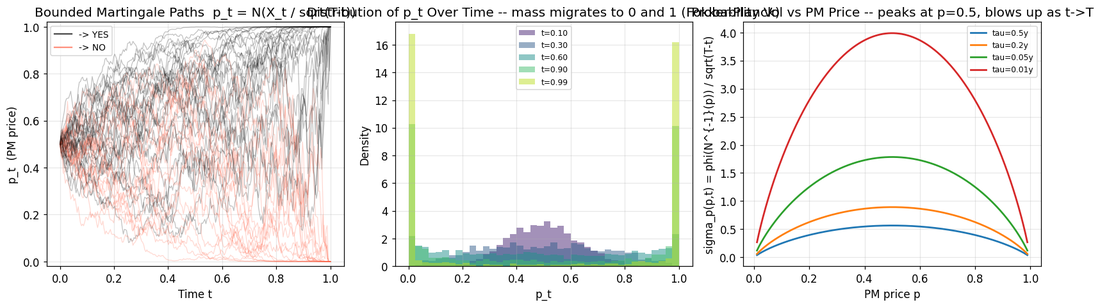

In [5]:
# Simulate latent Brownian paths and map to bounded martingale p_t
T_sim   = 1.0     # 1-year prediction market
n_paths = 2000
n_steps = 252     # daily steps
dt_sim  = T_sim / n_steps

t_grid   = np.linspace(0, T_sim, n_steps + 1)
tau_grid = T_sim - t_grid  # time remaining

# Simulate X_t = integral of dW, starting at X_0 = 0 (50/50 prior)
dW = rng.normal(0, np.sqrt(dt_sim), size=(n_paths, n_steps))
X  = np.zeros((n_paths, n_steps + 1))
X[:, 1:] = np.cumsum(dW, axis=1)

# p_t = N(X_t / sqrt(T - t)), handle t=T separately
eps = 1e-8
p   = np.zeros_like(X)
for j in range(n_steps):
    tau_j = tau_grid[j]
    p[:, j] = norm.cdf(X[:, j] / np.sqrt(tau_j + eps))
# At t=T: p = 1 if X_T > 0, else 0
p[:, -1] = (X[:, -1] > 0).astype(float)

# Terminal outcomes
n_yes = (p[:, -1] == 1).sum()
n_no  = (p[:, -1] == 0).sum()
print(f"Terminal outcomes (n={n_paths}): YES={n_yes} ({n_yes/n_paths:.1%}), NO={n_no} ({n_no/n_paths:.1%})")
print(f"(Expected ~50/50 from X_0=0)")

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# Panel A: sample paths
ax = axes[0]
sample_idx = rng.choice(n_paths, size=50, replace=False)
for idx in sample_idx:
    color = COLORS["analytic"] if p[idx, -1] == 1 else COLORS["longshot"]
    ax.plot(t_grid, p[idx, :], color=color, alpha=0.25, linewidth=0.8)
ax.plot([], [], color=COLORS["analytic"], alpha=0.7, linewidth=1.5, label="-> YES")
ax.plot([], [], color=COLORS["longshot"], alpha=0.7, linewidth=1.5, label="-> NO")
ax.set_xlabel("Time t")
ax.set_ylabel("p_t  (PM price)")
ax.set_title("Bounded Martingale Paths  p_t = N(X_t / sqrt(T-t))")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_ylim(-0.02, 1.02)

# Panel B: distribution of p_t at several time snapshots (Fokker-Planck)
ax2 = axes[1]
snapshot_times = [0.1, 0.3, 0.6, 0.9, 0.99]
snap_colors = plt.cm.viridis(np.linspace(0.1, 0.9, len(snapshot_times)))
for t_snap, col in zip(snapshot_times, snap_colors):
    j_snap = np.argmin(np.abs(t_grid - t_snap))
    vals = p[:, j_snap]
    ax2.hist(vals, bins=40, density=True, alpha=0.5, color=col,
             label=f"t={t_snap:.2f}", range=(0,1))
ax2.set_xlabel("p_t")
ax2.set_ylabel("Density")
ax2.set_title("Distribution of p_t Over Time -- mass migrates to 0 and 1 (Fokker-Planck)")
ax2.legend(fontsize=8, loc="upper center")
ax2.grid(True, alpha=0.3)

# Panel C: sigma_p(p, t) -- probability vol
ax3 = axes[2]
p_axis = np.linspace(0.01, 0.99, 400)
tau_vals   = [0.5, 0.2, 0.05, 0.01]
tau_labels = ["tau=0.5y", "tau=0.2y", "tau=0.05y", "tau=0.01y"]
for tau_v, lbl in zip(tau_vals, tau_labels):
    sigma_p = norm.pdf(norm.ppf(p_axis)) / np.sqrt(tau_v)
    ax3.plot(p_axis, sigma_p, label=lbl, linewidth=1.8)
ax3.set_xlabel("PM price p")
ax3.set_ylabel("sigma_p(p,t) = phi(N^{-1}(p)) / sqrt(T-t)")
ax3.set_title("Probability Vol vs PM Price -- peaks at p=0.5, blows up as t->T")
ax3.legend(fontsize=8)
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


---
## 5 | Implied 'Probability Vol' Calibration

Given an observed PM price path p_0, p_{t_1}, ..., p_{t_n}, we can back out an
**implied signal volatility** -- the analogue of backing out IV from an option price.

Recall p_t = N(X_t / sqrt(T-t)). If we observe p_t, we can recover X_t = N^{-1}(p_t) * sqrt(T-t).
The discrete variation of X_t provides an estimate of its instantaneous volatility, which
under the model equals 1. Deviations from 1 indicate model mismatch (non-Gaussian beliefs,
microstructure noise, favourite-longshot bias).

This is a simple analogy; the full calibration discussion is in the companion report.


Implied signal volatility (analogue of IV): 1.0565
True signal vol: 1.0000  (model is unit-vol BM)
Ratio (implied/true): 1.0565


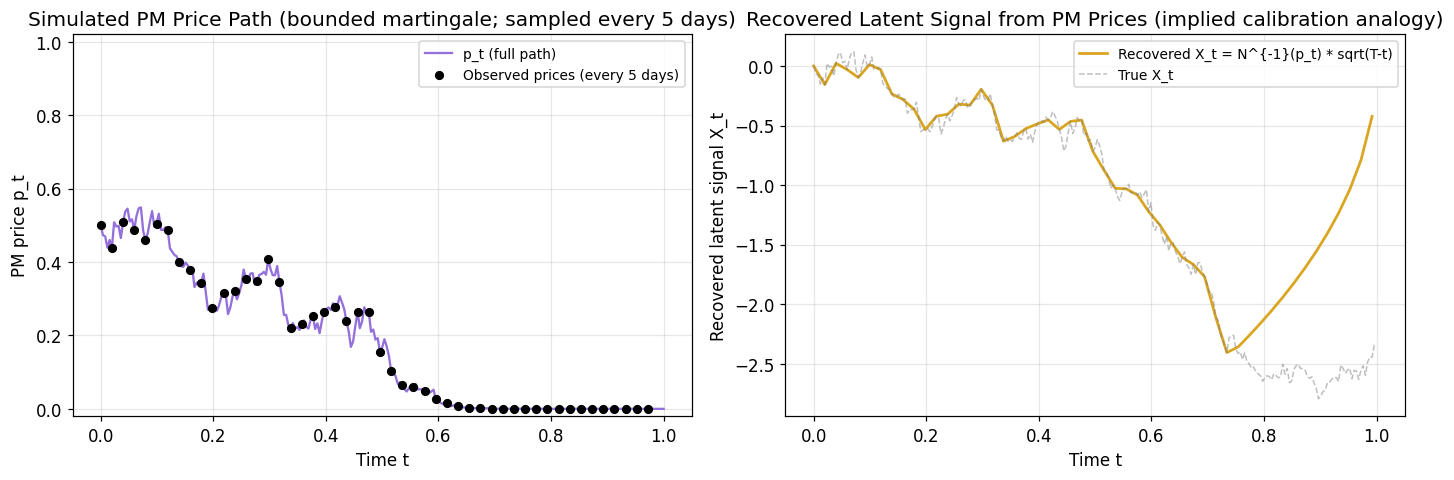

In [6]:
# Pick one simulated path and back out the implied signal vol
path_idx = 7   # fixed for reproducibility
p_path   = p[path_idx, :]
X_path   = X[path_idx, :]

# Observe p at every 5th step to simulate sparse market data
obs_steps = np.arange(0, n_steps, 5)
t_obs     = t_grid[obs_steps]
p_obs     = p_path[obs_steps]

# Recover X from observed p (exclude the last point where tau=0)
tau_obs      = tau_grid[obs_steps]
tau_obs_safe = np.where(tau_obs > 0, tau_obs, np.nan)
X_implied    = norm.ppf(np.clip(p_obs, 1e-6, 1 - 1e-6)) * np.sqrt(tau_obs_safe)

# Estimate realized vol from increments of X_implied
dX_implied = np.diff(X_implied[~np.isnan(X_implied)])
dt_obs     = 5 * dt_sim
realized_signal_vol = np.std(dX_implied) / np.sqrt(dt_obs)
print(f"Implied signal volatility (analogue of IV): {realized_signal_vol:.4f}")
print(f"True signal vol: 1.0000  (model is unit-vol BM)")
print(f"Ratio (implied/true): {realized_signal_vol:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

ax = axes[0]
ax.plot(t_grid, p_path, color=COLORS["path"], linewidth=1.5, label="p_t (full path)")
ax.scatter(t_obs[:-1], p_obs[:-1], color=COLORS["analytic"], s=25, zorder=5,
           label="Observed prices (every 5 days)")
ax.set_xlabel("Time t")
ax.set_ylabel("PM price p_t")
ax.set_title("Simulated PM Price Path (bounded martingale; sampled every 5 days)")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_ylim(-0.02, 1.02)

ax2 = axes[1]
valid_mask = ~np.isnan(X_implied)
ax2.plot(t_obs[valid_mask], X_implied[valid_mask], color=COLORS["signal"],
         linewidth=1.8, label="Recovered X_t = N^{-1}(p_t) * sqrt(T-t)")
ax2.plot(t_grid, X_path, color="grey", linewidth=1, alpha=0.5,
         linestyle="--", label="True X_t")
ax2.set_xlabel("Time t")
ax2.set_ylabel("Recovered latent signal X_t")
ax2.set_title("Recovered Latent Signal from PM Prices (implied calibration analogy)")
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


---
## 6 | Two Synthetic Example Contracts

### 6a -- 'SPY closes above X' Digital Contract

We model a synthetic 'SPY closes above 525 in 3 months' contract using the digital call pricer.
This is a standard use-case: an event defined by a financial index crossing a threshold.

### 6b -- Synthetic Election Contract (Longshot Behaviour)

We model a candidate starting with ~10% implied probability (a longshot).
Under the bounded-martingale model, most paths starting at p_0 ~ 0.10 resolve to 0 (loss),
but the few that win generate dramatic upswings -- characteristic of prediction market dynamics.


=== 6a: Synthetic SPY > 525 in 3m Contract ===
  S=500.0, K=525.0, T=0.25y, r=0.0438, sigma=0.15
  N(d2)              = 0.2939  (risk-neutral prob)
  Digital call price = 0.2907
  e^(-rT)*N(d2)      = 0.9891 * 0.2939 = 0.2907
  Implied prob ~29.4%

=== 6b: Longshot Election Contract (p0=0.1) ===
  Implied X_0 = N^(-1)(0.1) * sqrt(1.0) = -1.2816
  Simulated win rate: 200/2000 = 10.0% (theoretical: 10%)


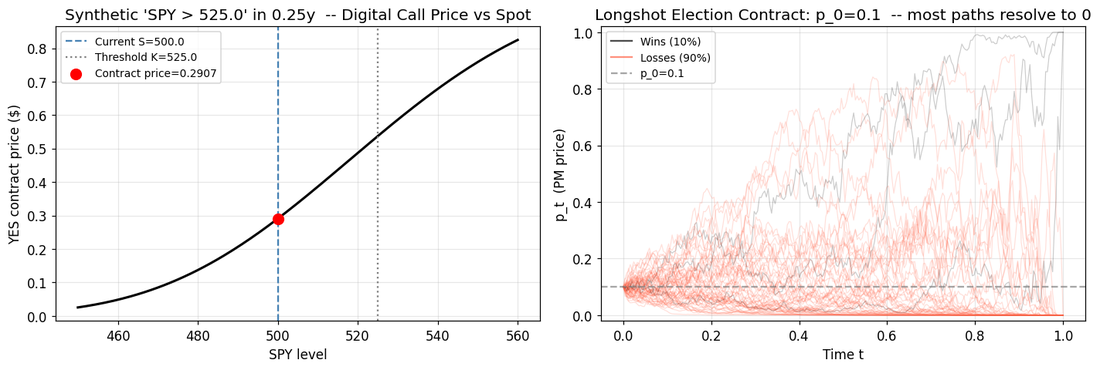

In [7]:
# 6a: "SPY closes above 525" digital contract
S_spy     = 500.0    # current SPY-like level
K_spy     = 525.0    # event threshold
T_spy     = 0.25     # 3 months
sigma_spy = 0.15     # typical equity-index vol

bs_spy   = BlackScholes(S_spy, K_spy, T_spy, r, sigma_spy)
dc_spy   = bs_spy.digital_call_price()
disc_spy = np.exp(-r * T_spy)
nd2_spy  = norm.cdf(bs_spy._d1_d2()[1])

print("=== 6a: Synthetic SPY > 525 in 3m Contract ===")
print(f"  S={S_spy}, K={K_spy}, T={T_spy}y, r={r:.4f}, sigma={sigma_spy}")
print(f"  N(d2)              = {nd2_spy:.4f}  (risk-neutral prob)")
print(f"  Digital call price = {dc_spy:.4f}")
print(f"  e^(-rT)*N(d2)      = {disc_spy:.4f} * {nd2_spy:.4f} = {disc_spy*nd2_spy:.4f}")
print(f"  Implied prob ~{nd2_spy*100:.1f}%")

# Plot YES price vs spot
S_spy_range = np.linspace(450, 560, 200)
yes_spy = [BlackScholes(S, K_spy, T_spy, r, sigma_spy).digital_call_price() for S in S_spy_range]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

ax = axes[0]
ax.plot(S_spy_range, yes_spy, color=COLORS["analytic"], linewidth=2)
ax.axvline(S_spy, color=COLORS["pde"],     linestyle="--", linewidth=1.5, label=f"Current S={S_spy}")
ax.axvline(K_spy, color="grey",            linestyle=":",  linewidth=1.5, label=f"Threshold K={K_spy}")
ax.scatter([S_spy], [dc_spy], color="red", s=80, zorder=5, label=f"Contract price={dc_spy:.4f}")
ax.set_xlabel("SPY level")
ax.set_ylabel("YES contract price ($)")
ax.set_title(f"Synthetic 'SPY > {K_spy}' in {T_spy}y  -- Digital Call Price vs Spot")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# 6b: Longshot election contract
p0_long = 0.10
X0_long = norm.ppf(p0_long) * np.sqrt(T_sim)
print(f"\n=== 6b: Longshot Election Contract (p0={p0_long}) ===")
print(f"  Implied X_0 = N^(-1)({p0_long}) * sqrt({T_sim}) = {X0_long:.4f}")

# Simulate paths starting from X0_long
dW_long = rng.normal(0, np.sqrt(dt_sim), size=(n_paths, n_steps))
X_long  = np.zeros((n_paths, n_steps + 1))
X_long[:, 0] = X0_long
X_long[:, 1:] = X0_long + np.cumsum(dW_long, axis=1)

p_long = np.zeros_like(X_long)
for j in range(n_steps):
    tau_j = tau_grid[j]
    p_long[:, j] = norm.cdf(X_long[:, j] / np.sqrt(tau_j + eps))
p_long[:, -1] = (X_long[:, -1] > 0).astype(float)

n_wins_long = (p_long[:, -1] == 1).sum()
print(f"  Simulated win rate: {n_wins_long}/{n_paths} = {n_wins_long/n_paths:.1%} (theoretical: {p0_long:.0%})")

ax2 = axes[1]
sample_long = rng.choice(n_paths, size=60, replace=False)
for idx in sample_long:
    color = COLORS["analytic"] if p_long[idx, -1] == 1 else COLORS["longshot"]
    ax2.plot(t_grid, p_long[idx, :], color=color, alpha=0.2, linewidth=0.8)
ax2.plot([], [], color=COLORS["analytic"], alpha=0.7, linewidth=1.5,
         label=f"Wins ({n_wins_long/n_paths:.0%})")
ax2.plot([], [], color=COLORS["longshot"], alpha=0.7, linewidth=1.5,
         label=f"Losses ({1-n_wins_long/n_paths:.0%})")
ax2.axhline(p0_long, color="grey", linestyle="--", linewidth=1.5, alpha=0.7, label=f"p_0={p0_long}")
ax2.set_xlabel("Time t")
ax2.set_ylabel("p_t  (PM price)")
ax2.set_title(f"Longshot Election Contract: p_0={p0_long}  -- most paths resolve to 0")
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)
ax2.set_ylim(-0.02, 1.02)

plt.tight_layout()
plt.show()


In [8]:
# Summary metrics table
def describe_series(series):
    """Compute descriptive statistics for a price/probability series."""
    return {
        "mean":   float(np.mean(series)),
        "std":    float(np.std(series)),
        "min":    float(np.min(series)),
        "max":    float(np.max(series)),
        "median": float(np.median(series)),
    }

# ATM digital call prices across maturities
T_list = [0.01, 0.05, 0.1, 0.25, 0.5, 1.0, 2.0]
atm_prices = [BlackScholes(K0, K0, T_v, r, sigma0).digital_call_price() for T_v in T_list]
atm_deltas = [BlackScholes(K0, K0, T_v, r, sigma0).digital_delta("call")  for T_v in T_list]
pde_atm    = [CrankNicolsonBS(K0, K0, T_v, r, sigma0, M=200, N=200).price("call", payoff="digital")
              for T_v in T_list]

df_summary = pd.DataFrame({
    "T (years)":           T_list,
    "Analytic price":      [round(v, 6) for v in atm_prices],
    "PDE price":           [round(v, 6) for v in pde_atm],
    "Abs error":           [f"{abs(p-a):.2e}" for p, a in zip(pde_atm, atm_prices)],
    "Digital delta (ATM)": [round(v, 4) for v in atm_deltas],
    "e^{-rT}":             [round(np.exp(-r*T_v), 6) for T_v in T_list],
}).set_index("T (years)")

print("ATM digital call: analytic vs PDE, across maturities (S=K=100, sigma=0.20)")
print(df_summary.to_string())

# Final parity check table
print("\nBinary put-call parity check (S=100, T=1y):")
K_parity = [80, 90, 100, 110, 120]
disc1 = np.exp(-r * T0)
for K_v in K_parity:
    bs_v  = BlackScholes(S0, K_v, T0, r, sigma0)
    yes_v = bs_v.digital_call_price()
    no_v  = bs_v.digital_put_price()
    print(f"  K={K_v:3d}: YES={yes_v:.6f}, NO={no_v:.6f}, sum={yes_v+no_v:.6f}, e^(-rT)={disc1:.6f}")


ATM digital call: analytic vs PDE, across maturities (S=K=100, sigma=0.20)
           Analytic price  PDE price Abs error  Digital delta (ATM)   e^{-rT}
T (years)                                                                    
0.01             0.504526   0.505076  5.50e-04               0.1994  0.999562
0.05             0.509497   0.509709  2.12e-04               0.0890  0.997812
0.10             0.512758   0.512895  1.37e-04               0.0628  0.995630
0.25             0.518020   0.518103  8.29e-05               0.0394  0.989110
0.50             0.521972   0.522030  5.78e-05               0.0275  0.978338
1.00             0.523905   0.523946  4.05e-05               0.0190  0.957145
2.00             0.519282   0.519310  2.85e-05               0.0127  0.916127

Binary put-call parity check (S=100, T=1y):
  K= 80: YES=0.853326, NO=0.103819, sum=0.957145, e^(-rT)=0.957145
  K= 90: YES=0.709050, NO=0.248096, sum=0.957145, e^(-rT)=0.957145
  K=100: YES=0.523905, NO=0.433240, sum=0.95

---
## 7 | Synthesis

### The binary lens and the PDE lens agree

This notebook demonstrated three consistent views of a prediction-market contract:

| View | Formula | Key result |
|------|---------|------------|
| BS closed form | C = e^{-rT} N(d2) | PM price = discounted risk-neutral probability |
| Crank-Nicolson PDE | Step payoff -> backward diffusion | Max error < 1e-3 vs analytic (Rannacher kills Gibbs) |
| Bounded martingale | p_t = N(X_t / sqrt(T-t)) | Zero drift, sigma_p blows up as t->T |

### Three key take-aways

1. **Hedging is intrinsically hard for binaries.** The digital delta spikes like a Dirac delta near
   expiry at the strike -- no finite hedge can replicate the discontinuous payoff without infinite
   trading costs. Dealers use tight call-spreads instead.

2. **Probability vol explodes near resolution.** sigma_p(p, t) = phi(N^{-1}(p)) / sqrt(T-t) -> infinity
   as t -> T, meaning even tiny new signals cause large PM price swings near the event date. This is a
   structural feature of bounded martingales, not a model defect.

3. **Longshot contracts have asymmetric path dynamics.** Starting from p_0 = 0.10,
   ~90% of paths resolve to 0 but the winning paths exhibit dramatic late-stage rallies --
   consistent with empirically observed favourite-longshot bias (though the model itself is
   calibrated-neutral).

### Limits of the analogy and further reading

The BS digital framework assumes GBM dynamics for the signal underlying the event, a complete
frictionless market, and risk-neutral pricing. Real PMs deviate via:
- **Favourite-longshot bias**: bettors overweight small probabilities (behavioural).
- **P vs Q measure gap**: the risk-neutral N(d2) may differ from real-world probabilities.
- **Thin markets / manipulation**: PM depth is finite; large trades move prices non-continuously.

The full theoretical discussion -- including the Fokker-Planck PDE for the density of p_t,
the Q-vs-P measure decomposition, and empirical evidence on favourite-longshot bias --
is in `reports/PREDICTION_MARKETS_AS_DERIVATIVES.md` (the companion prose report).
